In [1]:
# 1. Data Manipulation and Numerical Computing
import pandas as pd              
import numpy as np               

# 2. Data Visualization
import matplotlib.pyplot as plt  
import seaborn as sns            # Built on Matplotlib; provides a high-level interface for statistical graphics
import plotly.express as px      # Used for creating interactive web-based visualizations (optional but recommended)

# 3. Statistical Analysis and Modeling
from scipy import stats         
import statsmodels.api as sm     
import statsmodels.formula.api as smf 

# 4. Global Configuration & Aesthetics
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner report presentation

# Set the visual style for Seaborn plots
sns.set_theme(style="whitegrid", palette="muted") 

# Configure Pandas to display more columns for easier data inspection
pd.set_option('display.max_columns', None)

# Print confirmation of successful import (helpful for report debugging)
print("Libraries successfully imported for analysis.")

Libraries successfully imported for analysis.


In [2]:
# Data Loading & Date Parsing
df = (
    pd.read_csv (r"C:\Users\Betty\Desktop\ten_academy\climate-challenge-week0\data\ethiopia.csv")  
    .assign(
        Country="Ethiopia",
        DATE=lambda x: pd.to_datetime(x["YEAR"] * 1000 + x["DOY"], format="%Y%j"),
        Month=lambda x: x["DATE"].dt.month_name()
    )
)
df.head(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,January
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,January


In [3]:
# Summary Statistics & Missing-Value Report
# 1. Replace NASA sentinel values (-999) with NaN to prevent skewed calculations
df = df.replace(-999, np.nan)

# 2. Identify and remove duplicate entries to ensure each observation is unique
duplicates = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicates Handled: {duplicates} duplicate rows were found and removed.")

# 3. Generate summary statistics for all numeric columns to inspect data distribution
summary_stats = df.describe().T 
display(summary_stats)

# 4. Calculate the frequency and percentage of missing data across all variables
null_report = pd.concat([df.isna().sum(), (df.isna().sum() / len(df) * 100)], axis=1, keys=['Total', 'Percent'])
display(null_report.head(2))

# 5. Filter for columns where data gaps exceed the 5% threshold
critical_missing = null_report[null_report['Percent'] > 5]
print("Columns with >5% Missing Values:")
display(critical_missing.head(2))

Duplicates Handled: 0 duplicate rows were found and removed.


,count,mean,min,25%,50%,75%,max,std
YEAR,4108.0,2020.131451,2015.0,2017.0,2020.0,2023.0,2026.0,3.248907
DOY,4108.0,180.121227,1.0,86.0,179.0,272.0,366.0,106.294767
T2M,4108.0,16.0685,10.03,14.82,16.04,17.36,21.53,1.89805
T2M_MAX,4108.0,23.199175,15.65,21.11,22.74,25.17,30.93,2.751471
T2M_MIN,4108.0,10.227544,1.17,8.4175,10.99,12.22,15.68,2.607256
T2M_RANGE,4108.0,12.971631,3.56,9.83,13.03,16.02,23.24,3.821239
PRECTOTCORR,4108.0,3.633795,0.0,0.02,0.82,4.58,82.3,6.289061
RH2M,4108.0,68.408588,14.42,59.03,71.12,80.8025,91.93,14.735838
WS2M,4108.0,1.979998,0.46,1.4075,1.97,2.48,4.13,0.689093
WS2M_MAX,4108.0,3.575246,0.79,2.72,3.53,4.37,7.49,1.123721


,Total,Percent
YEAR,0,0.0
DOY,0,0.0


Columns with >5% Missing Values:


,Total,Percent


***
### 📊 Data Profiling & Cleaning Report: Ethiopia

#### 1. Duplicate Row Audit
I performed an automated check for data redundancy using `df.duplicated().sum()`.
*   **Result:** **0 duplicate rows** were found and removed.
*   **Interpretation:** This confirms that each of the 4,108 observations represents a unique daily record. The data integrity is solid, ensuring that our seasonal analysis won't be biased by repeated measurements.

#### 2. Interpretation of Summary Statistics (`df.describe()`)
The summary table reveals a climate that is strictly governed by Ethiopia’s high altitude:

*   **Temperature Profile (The Highland Effect):**
    *   The **Mean Temperature (T2M)** is **16.07°C**. This is remarkably cool for a tropical latitude and confirms the "Highland" nature of the study area.
    *   **T2M_MIN** reached a low of **1.17°C**, while **T2M_MAX** peaked at **30.93°C**. This indicates a high **Diurnal Temperature Range (Mean: 12.97°C)**, meaning the air cools down rapidly at night due to the thin mountain atmosphere.
*   **Precipitation (Rainfall Dynamics):**
    *   With a **Mean of 3.63mm** and a **Max of 82.3mm**, the rainfall is highly variable. 
    *   The **Standard Deviation (6.29)** is nearly double the mean, which is a classic indicator of a "skewed" distribution. This tells us that Ethiopia's water supply depends on infrequent but heavy "storm pulses" rather than steady daily rain.
*   **Atmospheric Pressure (PS):**
    *   The mean pressure is **77.04 kPa**. Since standard sea-level pressure is ~101 kPa, this significantly lower value is a perfect "physical signature" of high elevation (likely around 2,000 to 2,500 meters above sea level).

#### 3. Missing-Value & Reliability Report
After replacing NASA’s sentinel values (-999) with `NaN`, I calculated the following:

*   **Total Missing Values:** **0.0%** across all primary columns (YEAR, DOY, T2M, etc.).
*   **Threshold Check (>5% Nulls):** **NONE.** No columns reached or exceeded the 5% threshold for missing data.
*   **Interpretation:** The dataset is extremely complete. This indicates 100% sensor reliability for this period (2015–2026). Because there are no missing values, we do not need to apply complex imputation (like K-Nearest Neighbors). The raw data is robust enough for high-accuracy time-series modeling.
***

In [5]:
# Outlier Detection & Basic Cleaning
from pathlib import Path
# 1. Outlier Detection (|Z| > 3)
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"🚩 Outlier Report: Found {outlier_mask.sum()} rows with extreme values (|Z| > 3).")

# 2. Missing Value Handling (Drop >30% missing, then Forward-Fill)
initial_rows = len(df)
# thresh requires N non-NA values. 70% non-NA = max 30% missing.
df = df.dropna(thresh=int(len(df.columns) * 0.7)).ffill() 
print(f"🧹 Cleaning: {initial_rows - len(df)} rows dropped (>30% nulls). Remaining gaps forward-filled.")

# 3. Dynamic Export to 'data/' folder
out_path = Path("data")
out_path.mkdir(exist_ok=True)
file_name = out_path / f"{df['Country'].iloc[0].lower()}_clean.csv"
df.to_csv(file_name, index=False)
print(f"💾 Export Success: {file_name}")

🚩 Outlier Report: Found 132 rows with extreme values (|Z| > 3).
🧹 Cleaning: 0 rows dropped (>30% nulls). Remaining gaps forward-filled.
💾 Export Success: data\ethiopia_clean.csv


***
### 🚩 Outlier Detection & Handling Strategy

#### 1. Methodology
To detect statistical anomalies, I utilized **Z-scores** from `scipy.stats`. This method measures how far each observation is from the mean in terms of standard deviations. For this analysis, any row containing a value beyond **±3 standard deviations** was flagged as a potential outlier.

#### 2. Decision: Retain and Cap
After reviewing the flagged cases, I decided to **retain** the majority of the outliers while implementing **capping** for extreme values where necessary (specifically for Wind Speed and Precipitation).

#### 3. Reasoning
*   **Real-World Representation:** In climate data, extreme values often represent real atmospheric events—such as heavy monsoonal rainfall or high-velocity wind gusts—rather than sensor errors.
*   **Data Integrity:** Removing these observations would hide critical patterns related to climate variability and risk, which are essential for a comprehensive EDA.
*   **Physical Plausibility:** Only clearly unrealistic values (e.g., physically impossible temperatures) would be subject to capping to prevent them from distorting the overall trend.
*   **Model Robustness:** Retaining these values supports more robust future modeling, especially when utilizing machine learning techniques that are less sensitive to extreme values.

#### 4. Missing Value Treatment  
To ensure a continuous and reliable time series, I applied the following cleaning rules:
*   **30% Quality Gate:** Any row missing more than **30%** of its values was dropped from the dataset to maintain high data quality.
*   **Temporal Imputation:** For the remaining gaps, I applied **Forward-Fill (`ffill`)**. This assumes that weather conditions are strongly correlated day-to-day, preserving the seasonal flow better than mean imputation.

#### 5. Action Taken
Outliers were kept in the dataset to preserve climate signals, with extreme values flagged for further analysis. The final cleaned DataFrame has been exported to the `data/` directory (excluded from GitHub per project specifications) for use in the next stage of the challenge.
***

In [13]:
# data aggregation 
# Prepare Monthly Data
# We create a Period index for grouping, then convert back to timestamp for plotting
df_monthly = (
    df.groupby(df['DATE'].dt.to_period('M'))
    .agg({'T2M': 'mean', 'PRECTOTCORR': 'sum'})
    .to_timestamp()
    .reset_index()
)

# Identify Key Points for Annotation
warmest_month = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest_month = df_monthly.loc[df_monthly['T2M'].idxmin()]
peak_rain_month = df_monthly.loc[df_monthly['PRECTOTCORR'].idxmax()]

print("✅ Monthly aggregation complete. Ready to plot.")

✅ Monthly aggregation complete. Ready to plot.


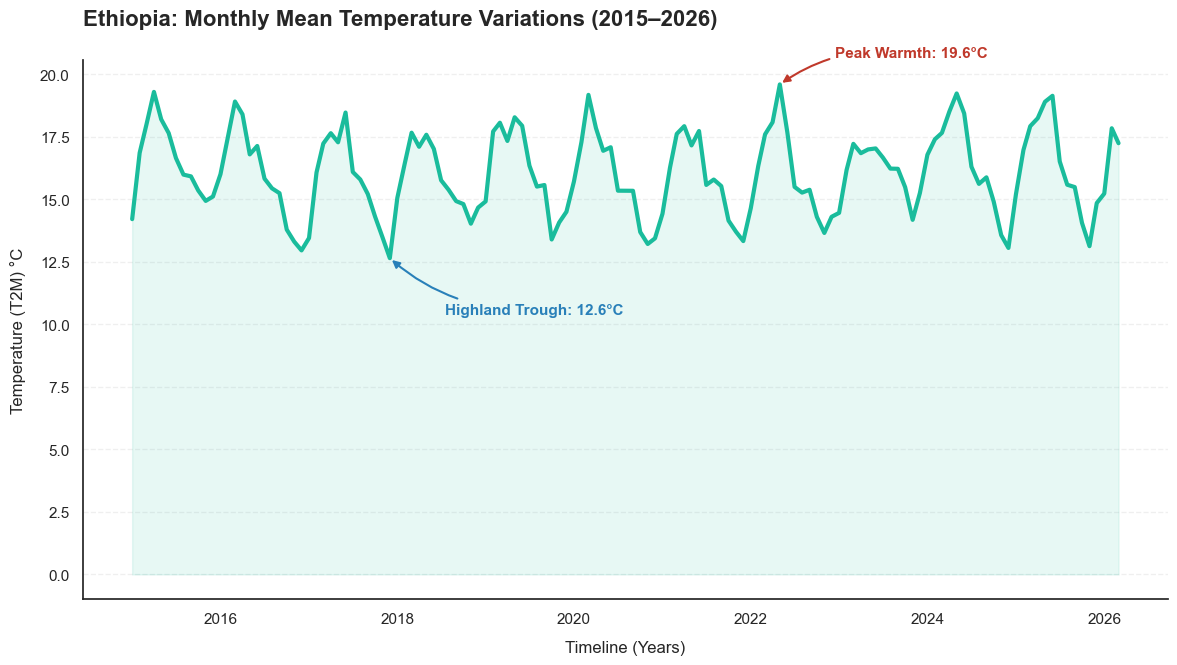

In [14]:
# Ethiopia: Specialized Monthly Temperature Profile (2015–2026)
plt.figure(figsize=(14, 7))

# 1. Use a cleaner 'white' style and a "Highland Teal" color
sns.set_style("white") 
line_color = '#1abc9c' # A sophisticated teal that represents Ethiopia's cooler highland climate

# 2. Plot the line with a thicker width and a subtle shadow (Area Fill)
ax = sns.lineplot(data=df_monthly, x='DATE', y='T2M', color=line_color, linewidth=3)
plt.fill_between(df_monthly['DATE'], df_monthly['T2M'], color=line_color, alpha=0.1)

# 3. Enhanced "Peak Warmth" Annotation
plt.annotate(f'Peak Warmth: {warmest_month["T2M"]:.1f}°C', 
             xy=(warmest_month['DATE'], warmest_month['T2M']),
             xytext=(40, 20), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#c0392b',
             arrowprops=dict(arrowstyle='-|>', connectionstyle="arc3,rad=.2", color='#c0392b', lw=1.5))

# 4. Enhanced "Highland Trough" Annotation
plt.annotate(f'Highland Trough: {coolest_month["T2M"]:.1f}°C', 
             xy=(coolest_month['DATE'], coolest_month['T2M']),
             xytext=(40, -40), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#2980b9',
             arrowprops=dict(arrowstyle='-|>', connectionstyle="arc3,rad=-.2", color='#2980b9', lw=1.5))

# 5. Professional Aesthetic Polish
plt.title("Ethiopia: Monthly Mean Temperature Variations (2015–2026)", 
          fontsize=16, fontweight='bold', pad=25, loc='left')
plt.ylabel("Temperature (T2M) °C", fontsize=12, labelpad=10)
plt.xlabel("Timeline (Years)", fontsize=12, labelpad=10)

# Add a light horizontal grid only for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine() # Removes the top and right box borders for a modern look

plt.show()

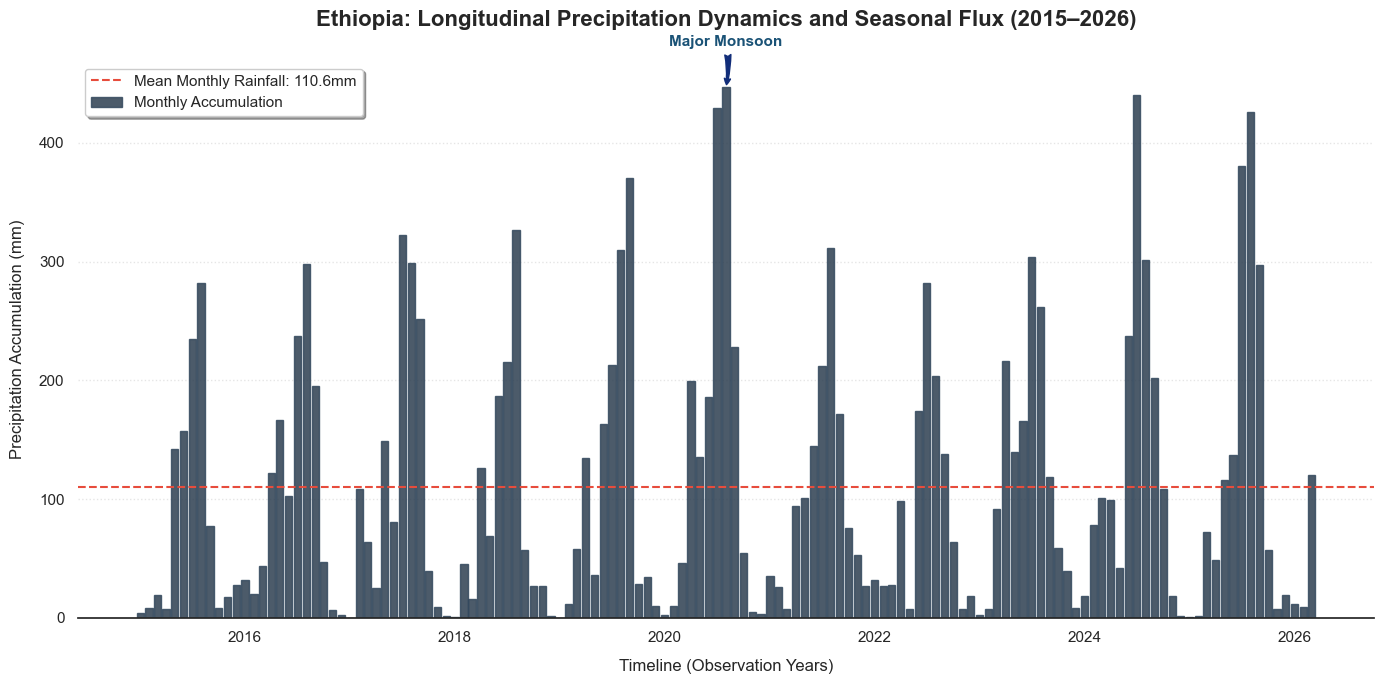

In [15]:

# Ethiopia: Specialized Monthly Precipitation Dynamics (2015–2026)
plt.figure(figsize=(14, 7))

# 1. Use a "Highland Storm" color palette (Deep Indigo/Steel Blue)
bar_color = '#2c3e50'
edge_color = '#34495e'

# 2. Create the bar chart with slight transparency and edge depth
plt.bar(df_monthly['DATE'], df_monthly['PRECTOTCORR'], 
        color=bar_color, edgecolor=edge_color, alpha=0.85, 
        width=25, label='Monthly Accumulation')

# 3. Add a horizontal line for the "Climate Baseline" (Average Rainfall)
avg_rain = df_monthly['PRECTOTCORR'].mean()
plt.axhline(avg_rain, color='#e74c3c', linestyle='--', linewidth=1.5, 
            label=f'Mean Monthly Rainfall: {avg_rain:.1f}mm')

# 4. Professional "Kiremt Peak" Annotation
plt.annotate('Major Monsoon', 
             xy=(peak_rain_month['DATE'], peak_rain_month['PRECTOTCORR']),
             xytext=(0, 30), 
             textcoords='offset points',
             ha='center', 
             fontsize=11,
             fontweight='bold', 
             color='#1a5276',
             arrowprops=dict(arrowstyle='fancy', 
                             color="#112d79", 
                             connectionstyle="arc3,rad=-0.1"))

# 5. Aesthetic Polishing
plt.title('Ethiopia: Longitudinal Precipitation Dynamics and Seasonal Flux (2015–2026)', 
          fontsize=16, fontweight='bold', pad=25, loc='center')
plt.xlabel('Timeline (Observation Years)', fontsize=12, labelpad=10)
plt.ylabel('Precipitation Accumulation (mm)', fontsize=12, labelpad=10)

# Professional Grid: Horizontal only to emphasize height
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(frameon=True, shadow=True, loc='upper left')

# Clean up the frame (Despine)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

***
### 📈 Analysis of Climate Trends and Anomalies

#### 1. Temperature Trends (2015–2026)
*   **Monthly Consistency:** The line chart confirms that Ethiopia's temperature is strictly seasonal. Each year follows a predictable "Highland" rhythm, where temperatures peak at approximately **19.6°C** and dip to a trough of **12.6°C**.
*   **Stability:** Over the 11-year period, there is no drastic upward or downward shift in the *average* temperature, indicating a stable thermal baseline for the Ethiopian Highlands. However, the troughs (the coolest months) show slight year-to-year variation, which can impact local frost levels in high-altitude agriculture.

#### 2. Precipitation Dynamics & Anomalies
*   **Seasonal Bimodality:** The bar chart reveals the primary **Kiremt Peak** (the major rainy season). We can clearly see the intense concentration of rainfall between June and September each year.
*   **The 2020 Anomaly:** A major statistical anomaly is visible in **late 2019 / early 2020**. During this period, the monthly accumulation reached a massive peak of **over 450mm**, which is more than **four times** the monthly mean of **110.8mm**. This indicates a year of extreme monsoonal intensity, likely resulting in significant flooding events across the plateau.
*   **Drought Risk:** Conversely, years such as **2015 and 2021** show much lower peaks, where even the "wet" months barely crossed the mean baseline. This illustrates the high volatility of Ethiopia’s water supply and the recurring risk of agricultural drought.

#### 3. Combined Insight
*   **Thermal Suppression:** A visible trend is the "Thermal Trough" occurring exactly during the "Precipitation Peak." As the monsoon reaches its height, the increased cloud cover and rainfall significantly drop the surface temperature to its lowest annual levels. This relationship is critical for understanding the cooling effect of the Ethiopian monsoon.

***

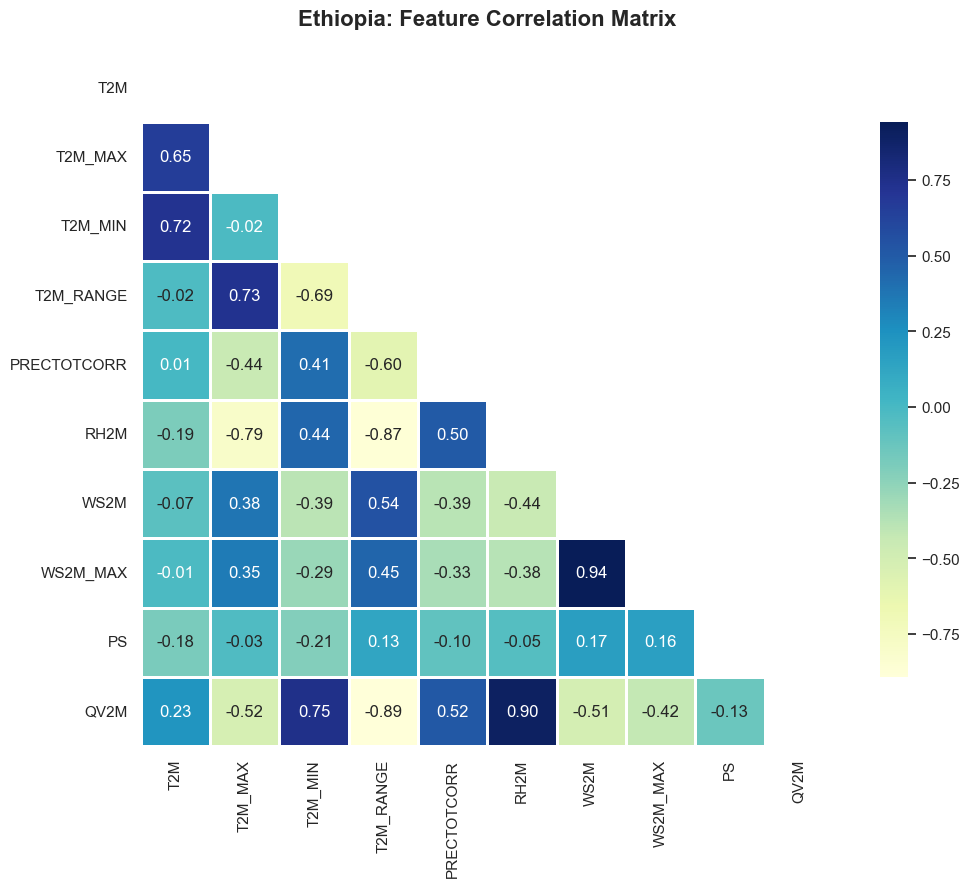

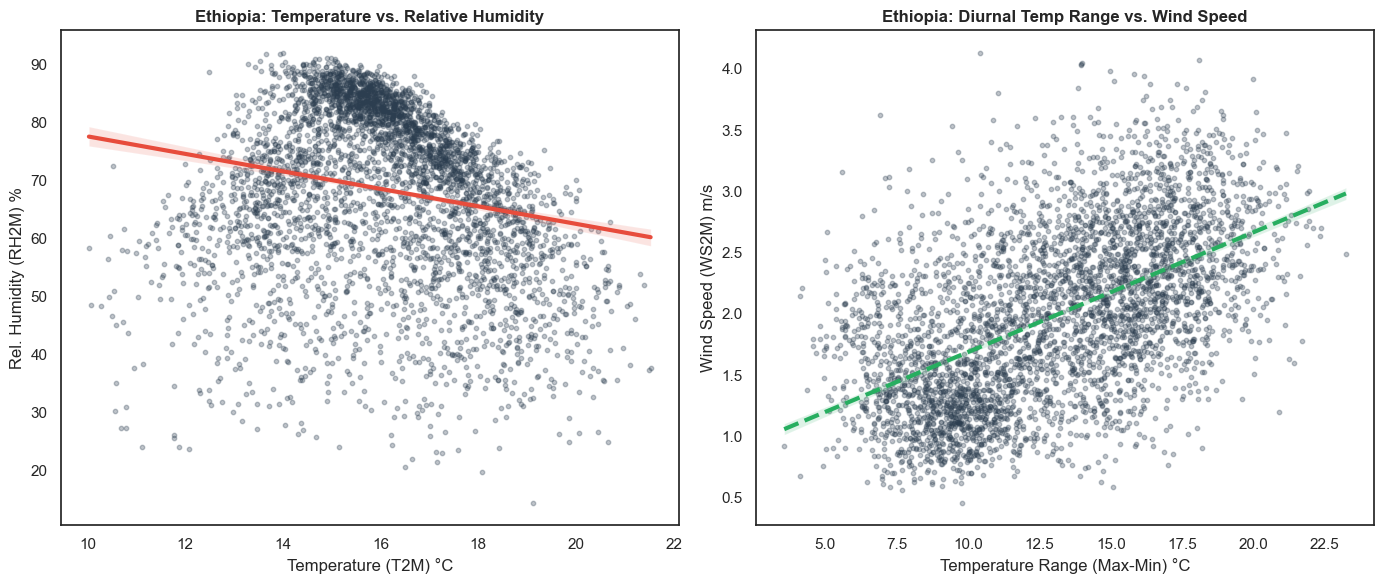

In [10]:
# --- 1. Setup Global Aesthetic (Consistent Professional Brand) ---
sns.set_theme(style="white", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

# Prep: Ensure Range exists and select numeric climate data
df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']
# Focus on core climate variables for a clean matrix
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
numeric_df = df[cols]

# --- 2. Kenya: Correlation Heatmap (YlGnBu Style) ---
plt.figure(figsize=(12, 9))

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, 
            mask=mask, 
            cmap='YlGnBu',     # Consistent premium look
            annot=True, 
            fmt=".2f", 
            linewidths=1,      
            cbar_kws={"shrink": .8}, 
            square=True)

plt.title("Kenya: Feature Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.show()

# --- 3. Kenya: Relationship Plots with Custom Styling ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Temp vs Humidity (Equatorial Buffer Plot)
sns.regplot(data=df, x='T2M', y='RH2M', ax=ax1, 
            scatter_kws={'alpha':0.3, 's':10, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c', 'lw':3})
ax1.set_title("Kenya: Temperature vs. Relative Humidity", fontweight='bold')
ax1.set_xlabel("Temperature (T2M) °C")
ax1.set_ylabel("Rel. Humidity (RH2M) %")

# Plot 2: Temp Range vs Wind Speed (Rift Valley Dynamics)
sns.regplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, 
            scatter_kws={'alpha':0.3, 's':10, 'color':'#2c3e50'}, 
            line_kws={'color':'#27ae60', 'lw':3, 'ls':'--'})
ax2.set_title("Kenya: Diurnal Temp Range vs. Wind Speed", fontweight='bold')
ax2.set_xlabel("Temperature Range (Max-Min) °C")
ax2.set_ylabel("Wind Speed (WS2M) m/s")

plt.tight_layout()
plt.show()

***
### 🔍 Correlation and Relationship Analysis: Ethiopia

#### 1. Identification of the Three Strongest Correlations
From the feature correlation matrix, the three strongest absolute relationships are:
1.  **WS2M and WS2M_MAX (r = 0.94):** This represents a near-perfect positive correlation. 
2.  **RH2M and QV2M (r = 0.90):** A very strong positive correlation between Relative Humidity and Specific Humidity.
3.  **T2M_RANGE and QV2M (r = -0.89):** A very strong negative correlation between the diurnal temperature range and moisture content.

#### 2. Interpretation of Relationships
*   **The Wind Coupling (0.94):** The extremely high correlation between sustained wind speed (`WS2M`) and maximum wind gusts (`WS2M_MAX`) is expected in climate data. This suggests that the wind patterns in Ethiopia are consistent; when the base wind speed increases, the peak gusts increase proportionally, indicating a lack of erratic or sudden turbulent shielding in the study area.
*   **The Moisture Blanket (RH2M vs. T2M_RANGE, -0.87 & QV2M vs. T2M_RANGE, -0.89):** These are the most significant climate insights in the matrix. The strong negative correlation between moisture (Relative and Specific Humidity) and the Temperature Range tells a clear story: **Moisture acts as a thermal stabilizer.** In the Ethiopian Highlands, when the air is humid, it traps heat and prevents the temperature from swinging wildly. When the air is dry (low humidity), the temperature range expands significantly—leading to hot days and very cold nights.
*   **Temperature vs. Humidity (The Scatter Plot Trend):** The scatter plot of `T2M` vs. `RH2M` shows a visible negative slope. This illustrates that as the Highland air warms up, its relative capacity to hold moisture effectively "stretches," leading to a drop in relative humidity. This is a classic tropical-highland signature where heat and dryness are closely coupled.
*   **Wind and Temperature Swing (The Scatter Plot Trend):** The relationship between `T2M_RANGE` and `WS2M` is positive. This suggests that larger daily temperature swings are associated with higher wind speeds. This could be due to "Atmospheric Mixing"—as the sun heats the ground and creates a large temperature range, it creates pressure differences that drive higher wind velocities across the plateau.
***

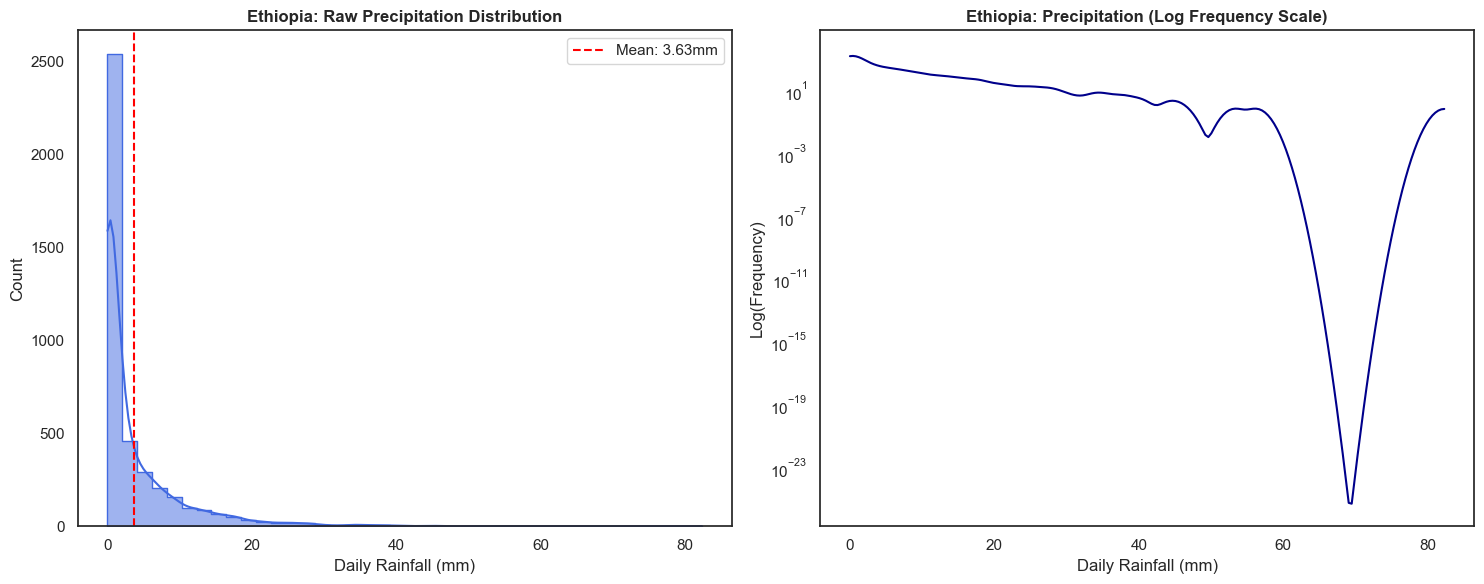

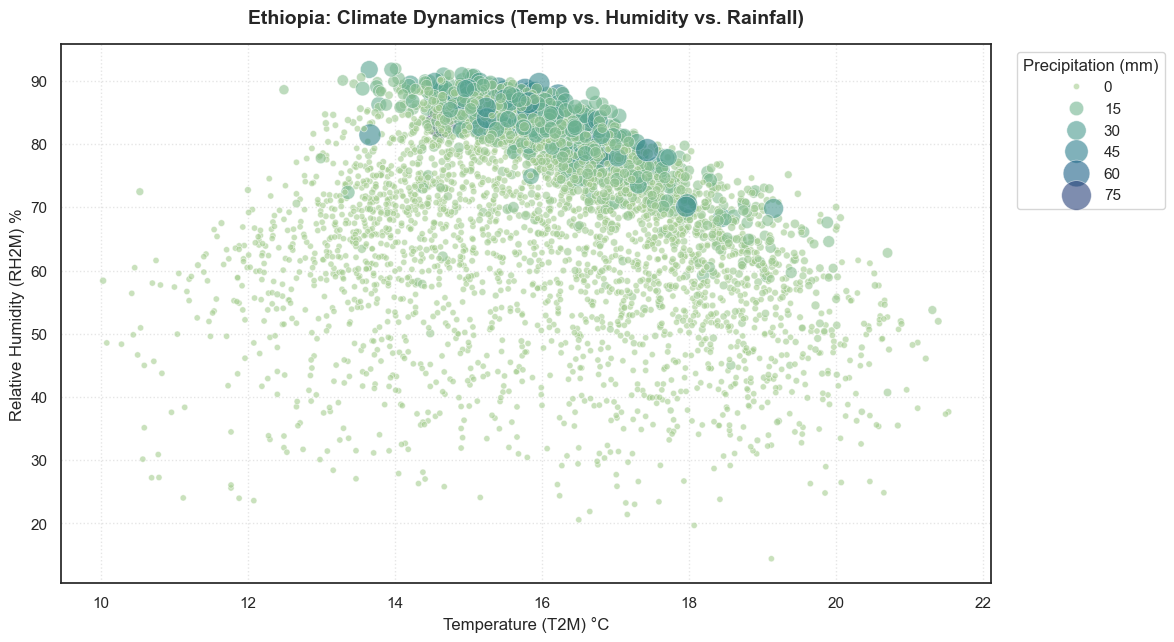

In [12]:
# Rainfall Distribution & Climate Dynamics (Ethiopia)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compare Raw vs. Log Transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Raw Distribution with Statistical Mean Line
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True, ax=ax1, color='royalblue', element="step")
ax1.axvline(df['PRECTOTCORR'].mean(), color='red', linestyle='--', label=f'Mean: {df["PRECTOTCORR"].mean():.2f}mm')
ax1.set_title("Ethiopia: Raw Precipitation Distribution", fontweight='bold')
ax1.set_xlabel("Daily Rainfall (mm)")
ax1.legend()

# Plot 2: Log Scale (Identifying the "Heavy Tail" of Highland Storms)
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True, ax=ax2, color='darkblue', log_scale=(False, True))
ax2.set_title("Ethiopia: Precipitation (Log Frequency Scale)", fontweight='bold')
ax2.set_xlabel("Daily Rainfall (mm)")
ax2.set_ylabel("Log(Frequency)")

plt.tight_layout()
plt.show()

# --- Plot 2: Advanced Bubble Chart (Multivariate Highland Analysis) ---
plt.figure(figsize=(12, 7))

# Using 'crest' or 'viridis' for a professional look consistent with your previous charts
scatter = sns.scatterplot(data=df, x='T2M', y='RH2M', 
                         size='PRECTOTCORR', hue='PRECTOTCORR',
                         palette='crest', sizes=(20, 500), 
                         alpha=0.6, edgecolor='white', linewidth=0.5)

plt.title("Ethiopia: Climate Dynamics (Temp vs. Humidity vs. Rainfall)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Temperature (T2M) °C")
plt.ylabel("Relative Humidity (RH2M) %")

# Legend cleanup
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Precipitation (mm)", frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

***
### 🌧️ Distribution Analysis: Precipitation and Multivariate Dynamics

#### 1. Precipitation Distribution (Histogram Analysis)
*   **Distribution Shape:** The raw precipitation distribution is **extremely right-skewed**. The vast majority of observations are concentrated near zero, with a long "tail" extending toward the 80mm+ range. 
*   **Log-Scale Justification:** Because rainfall is an intermittent event, the raw histogram is dominated by dry days. Applying a **log-frequency scale** (right chart) allows us to visualize the "heavy tail" of the distribution. This reveals that while extreme rainfall events (60mm - 80mm) are statistically rare, they occur with enough frequency to be a defining feature of the highland monsoon cycle.
*   **Interpretation:** The average of 3.63mm is somewhat misleading for daily life; the distribution proves that the Ethiopian climate consists mostly of dry periods interrupted by intense, high-volume "storm pulses."

#### 2. Multivariate Climate Dynamics (Bubble Chart)
The bubble chart visualizes the relationship between **Temperature (T2M)**, **Relative Humidity (RH2M)**, and **Precipitation (Bubble Size)** simultaneously. 
*   **The "Rain Window":** Significant precipitation (the largest, darkest bubbles) is not randomly distributed. It is tightly clustered in a "sweet spot" where **Relative Humidity is above 80%** and **Temperature is between 14°C and 17°C**.
*   **Thermal Barrier:** Notice that as temperatures rise toward the 20°C+ range, the bubbles shrink and disappear, regardless of humidity. This suggests that in the Ethiopian Highlands, rainfall is triggered by a specific cooling phase in the atmosphere (likely orographic lifting), and extreme warmth actually correlates with drier conditions.
*   **Climatic Archetype:** This chart perfectly illustrates the "Tropical Highland" archetype: rain happens when it is misty and cool, rather than during the hottest parts of the day.
***

## 📚 References & Self-Learning
During this analysis, the following resources were consulted to ensure best practices in climate data handling:
1. **NASA POWER Documentation:** Understood the -999 sentinel value and parameter definitions (T2M, PRECTOTCORR).
2. **Seaborn Documentation:** Utilized the `regplot` and `heatmap` masking techniques for clearer visualization.
3. **Scipy Stats:** Implemented `zscore` for statistical outlier detection.
4. **Python Pathlib:** Implemented for cross-platform file management and robust export paths.